# Centrioles and nuclei tracking

## Dataset: 30hpf CetnEos, H2BmCherry, CS

In this scipt, I regoup my investigation about centrioles and nuclei tracking.

In [1]:
import tifffile
import numpy as np
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from pandas import DataFrame, Series  # for convenience
from pathlib import Path
from rich.pretty import pprint
import cv2

import trackpy as tp
import btrack
from ultrack import MainConfig, load_config, track, to_tracks_layer, tracks_to_zarr
from ultrack.imgproc import robust_invert, detect_foreground
from ultrack.utils import estimate_parameters_from_labels, labels_to_contours
from ultrack.utils.array import array_apply, create_zarr
from ultrack.config import MainConfig

import warnings

import sys

my_path = Path.cwd().parent.parent / "src"
sys.path.append(str(my_path))

from visualization import visualization
from utils import utils

%matplotlib inline

In [2]:
ROOT = Path(r"K:\users\voland\images\data\TgCetnEos_CenSpark_H2B_4h-24h-48hpf\20260506CFHc_CetnEos_H2BmCherry_CS_30hpf_25-63x\5e3c_25x_zoom3_TL\subset\subset_tracking")

VOL_PATH = ROOT/"20260506CFHc_CetnEos_H2BmCherry_CS_30hpf_25-63x.lif - 5e3c_25x_zoom3_TL-2.tif"

In [3]:
CT_CHANNEL_ID = 0
NUCL_CHANNEL_ID = 1
BF_CHANNEL_ID = 3

CT_ANNOTATION_CHANNEL_ID = 1

In [94]:
vol = tifffile.imread(VOL_PATH)
ct_vol = vol[:,:,CT_CHANNEL_ID]
nucl_vol = vol[:,:,NUCL_CHANNEL_ID]
bf_vol = vol[:,:,BF_CHANNEL_ID]

# Centrioles tracking

## Data loading

In [5]:
CT_CENTERS_PATH = ROOT /"detection"/"centrioles"/"ct_res"/"c1_centers.csv"
CT_CENTERS_VOL_PATH = ROOT/"detection"/"centrioles"/"ct_res"/"c1_detection_img.tif"

CT_TRACKPY_VOL_PATH = ROOT /"tracking"/"centrioles"/"trackpy"/"trackpy_vol.tif"
CT_TRACKPY_VOL_PATH = ROOT /"tracking"/"centrioles"/"trackpy"/"trackpy_data.csv"

CT_BTRACK_RES_PATH = ROOT /"tracking"/"centrioles"/"btrack"/"btrack_vol.h5"
CT_BTRACK_PARTICLE_VOL_PATH = ROOT /"tracking"/"centrioles"/"btrack"/"btrack_particle_vol.tif"
CT_BTRACK_PARTICLE_DATA_PATH = ROOT /"tracking"/"centrioles"/"btrack"/"btrack_particle_data.csv"

CT_BTRACK_CELL_VOL_PATH = ROOT /"tracking"/"centrioles"/"btrack"/"btrack_cell_vol.tif"
CT_BTRACK_CELL_DATA_PATH = ROOT /"tracking"/"centrioles"/"btrack"/"btrack_cell_data.csv"

BTRACK_PARTICLE_MODEL_PATH = Path("../../models/btrack/particle_config.json")
BTRACK_CELL_MODEL_PATH = Path("../../models/btrack/cell_config.json")

In [6]:
ct_centers_vol = tifffile.imread(CT_CENTERS_VOL_PATH)
ct_centers_vol_annotated = ct_centers_vol[:,:,CT_ANNOTATION_CHANNEL_ID]

In [7]:
ct_centers = pd.read_csv(CT_CENTERS_PATH)
ct_centers.head()

,index,T,Z,Y,X,R
0,0,0.0,7.0,56.0,136.0,1.982942
1,1,0.0,10.0,137.0,64.0,1.982942
2,2,0.0,6.0,93.0,117.0,1.982942
3,3,0.0,13.0,158.0,27.0,1.982942
4,4,0.0,13.0,80.0,131.0,1.982942


Here are the type of foci present on our images.

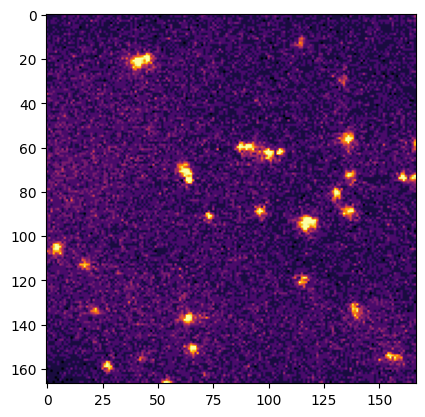

In [8]:
ct_vol = vol[:,:,CT_CHANNEL_ID]

ct_vol_max = np.max(ct_vol[0],axis=0)
plt.imshow(ct_vol_max, cmap="inferno")

Let's verify the number of foci detected at each frame.

In [9]:
ct_centers.groupby("T").index.count()

T
0.0    34
1.0    26
2.0    25
3.0    23
Name: index, dtype: int64

Also let's get our coordinates in um

In [10]:
resolution = utils.get_pixel_size(VOL_PATH)
ct_centers[["Zum","Yum","Xum"]] = ct_centers[["Z","Y","X"]] * resolution

## TrackPy

The first method I tried is reported and presented in this [notebook](https://github.com/bnsreenu/python_for_microscopists/blob/master/289_tracking_particles_in_3D.ipynb).

In [11]:
fcenters_ct = ct_centers.copy()
fcenters_ct = fcenters_ct.rename(columns={"T": "frame"})
fcenters_ct.head()

,index,frame,Z,Y,X,R,Zum,Yum,Xum
0,0,0.0,7.0,56.0,136.0,1.982942,3.978733,8.472258,20.575484
1,1,0.0,10.0,137.0,64.0,1.982942,5.683904,20.726775,9.682581
2,2,0.0,6.0,93.0,117.0,1.982942,3.410342,14.070000,17.700968
3,3,0.0,13.0,158.0,27.0,1.982942,7.389075,23.903871,4.084839
4,4,0.0,13.0,80.0,131.0,1.982942,7.389075,12.103226,19.819033


Frame 3: 23 trajectories present.


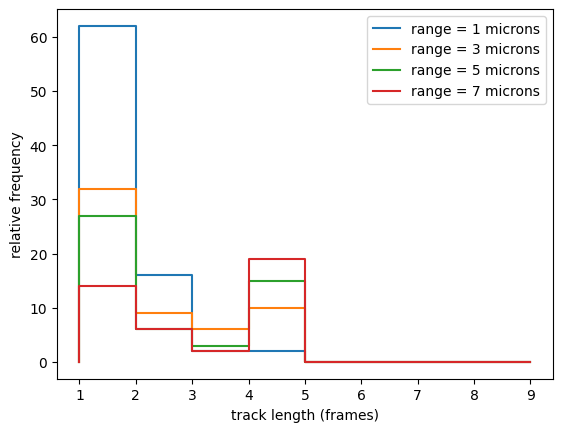

In [12]:
for search_range in range(1,8,2):
    linked = tp.link_df(fcenters_ct, search_range, pos_columns=["Zum","Yum","Xum"])
    hist, bins = np.histogram(np.bincount(linked.particle.astype(int)),
                              bins=np.arange(10))
    plt.step(bins[1:], hist, label='range = {} microns'.format(search_range))
plt.ylabel('relative frequency')
plt.xlabel('track length (frames)')
plt.legend()

We should determine the distance we want for our tracks

In [13]:
linked = tp.link_df(fcenters_ct, 7,pos_columns=["Zum","Yum","Xum"])
print(f"Number of trajectories found: {linked['particle'].max()}")
linked

Frame 3: 23 trajectories present.
Number of trajectories found: 40


,index,frame,Z,Y,X,R,Zum,Yum,Xum,particle
0,0,0,7.0,56.0,136.0,1.982942,3.978733,8.472258,20.575484,0
1,1,0,10.0,137.0,64.0,1.982942,5.683904,20.726775,9.682581,1
2,2,0,6.0,93.0,117.0,1.982942,3.410342,14.070000,17.700968,2
3,3,0,13.0,158.0,27.0,1.982942,7.389075,23.903871,4.084839,3
4,4,0,13.0,80.0,131.0,1.982942,7.389075,12.103226,19.819033,4
...,...,...,...,...,...,...,...,...,...,...
103,103,3,0.0,29.0,71.0,1.982942,0.000000,4.387419,10.741613,25
104,104,3,0.0,102.0,92.0,1.982942,0.000000,15.431613,13.918710,40
105,105,3,0.0,127.0,33.0,1.982942,0.000000,19.213871,4.992581,16
106,106,3,13.0,139.0,85.0,1.982942,7.389075,21.029355,12.859678,1


### Analysis

#### Mean square displacement

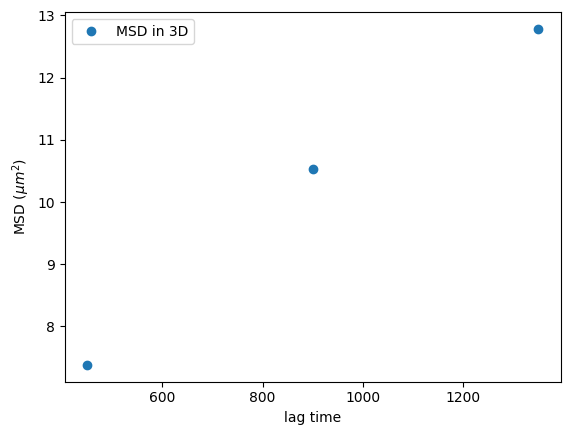

In [14]:
msd3D = tp.emsd(linked, mpp=1, fps=1/(7.50*60), pos_columns=["Xum","Yum","Zum"])
ax = msd3D.plot(style='o', label='MSD in 3D')
ax.set_ylabel(r'MSD ($\mu m^2$)')
ax.set_xlabel("lag time")
ax.legend(loc='upper left')
     

The diffusion constant is 0.00 μm²/s


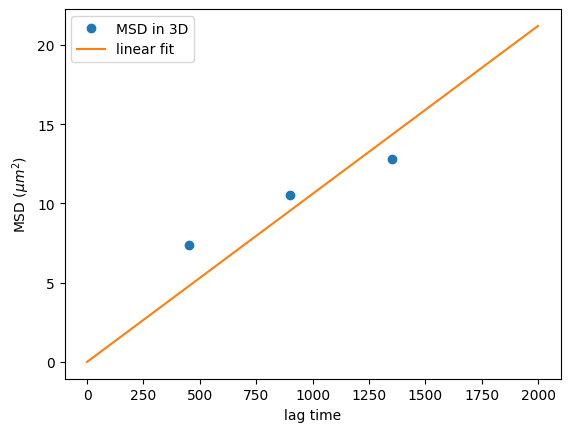

In [15]:
slope = np.linalg.lstsq(np.array(msd3D.index)[:, np.newaxis], msd3D)[0][0]

ax = msd3D.plot(style='o', label='MSD in 3D')
ax.plot(np.arange(2000), slope * np.arange(2000), label='linear fit')
ax.set_ylabel(r'MSD ($\mu m^2$)')
ax.set_xlabel("lag time")
ax.legend(loc='upper left')
print(r'The diffusion constant is {0:.2f} μm²/s'.format(slope / 6))

### Save the results 

In [16]:
t,z,y,x = ct_vol
tracking_id_mask = np.zeros(ct_vol.shape,dtype = ct_vol.dtype)
t = ct_vol.shape[0]
for ti in range(t):  
    tracking_centers = linked.loc[linked["frame"]==ti][["Z","Y","X"]].values.astype(int)
    tracking_id = linked.loc[linked["frame"]==ti]["particle"].values.astype(str)

    tracking_id_mask[ti] = visualization.add_texts(tracking_id_mask[ti], tracking_id, tracking_centers, fontScale=0.4)

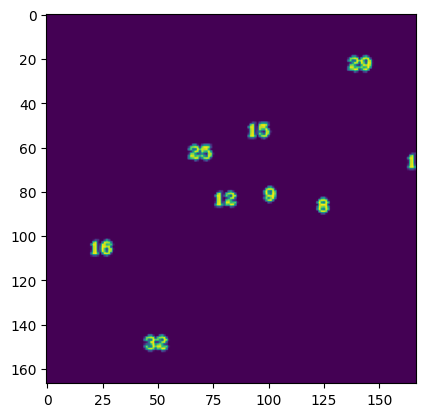

In [17]:
plt.imshow(tracking_id_mask[0,0])

In [18]:
trackpy_ct_vol = np.stack([ct_vol, ct_centers_vol_annotated,tracking_id_mask,bf_vol],axis=2)

In [19]:
tifffile.imwrite(CT_TRACKPY_VOL_PATH, trackpy_ct_vol,imagej=True,compression="zlib")

This works mostly well

## Btrack

Based on the signle example from their [website](https://btrack.readthedocs.io/en/latest/user_guide/simple_example.html).

As Btrack takes segmentated images, we can either create a tracking mask from our coordinates or maybe use the yen thresholding.

In [20]:
t, zlim, ylim,xlim = ct_vol.shape

Let's first try with the particle model.

In [21]:
objects = []

for idx, row in ct_centers.iterrows():
    obj = btrack.btypes.PyTrackObject()
    obj.t = int(row['T'])
    obj.x = float(row['Xum'])
    obj.y = float(row['Yum'])
    obj.z = float(row['Zum'])
    obj.ID = idx  # Original index for reference
    
    objects.append(obj)

with btrack.BayesianTracker() as tracker:

    # configure the tracker using a config file
    tracker.configure(BTRACK_PARTICLE_MODEL_PATH)

    # append the objects to be tracked
    tracker.append(objects)

    # set the volume (Z axis volume limits default to [-1e5, 1e5] for 2D data)
    xmax = xlim * resolution[2]
    ymax = ylim * resolution[1]
    zmax = zlim * resolution[0]
    tracker.volume = ((0, xmax), (0, ymax), (0, zmax))

    tracker.max_search_radius = 7

    # track them (in interactive mode)
    tracker.track_interactive(step_size=100)

    # generate hypotheses and run the global optimizer
    tracker.optimize()

    # get the tracks as a python list
    tracks = tracker.tracks

    # optional: get the data in a format for napari
    data, properties, graph = tracker.to_napari()

    tracker.export(CT_BTRACK_RES_PATH, obj_type='obj_type_1')

[INFO][2026/06/08 10:11:41 AM] Loaded btrack: C:\Users\voland\.conda\envs\tracking-env\Lib\site-packages\btrack\libs\libtracker.DLL
INFO:btrack.libwrapper:Loaded btrack: C:\Users\voland\.conda\envs\tracking-env\Lib\site-packages\btrack\libs\libtracker.DLL
[INFO][2026/06/08 10:11:41 AM] Starting BayesianTracker session
INFO:btrack.core:Starting BayesianTracker session
[INFO][2026/06/08 10:11:41 AM] Loading configuration file: ..\..\models\btrack\particle_config.json
INFO:btrack.config:Loading configuration file: ..\..\models\btrack\particle_config.json
[INFO][2026/06/08 10:11:41 AM] Objects are of type: <class 'list'>
INFO:btrack.io.utils:Objects are of type: <class 'list'>
[WARNING][2026/06/08 10:11:41 AM] `track_interactive` will be deprecated. Use `track` instead.
[INFO][2026/06/08 10:11:41 AM] Starting tracking... 
INFO:btrack.core:Starting tracking... 
[INFO][2026/06/08 10:11:41 AM] Update using: ['MOTION']
INFO:btrack.core:Update using: ['MOTION']
[INFO][2026/06/08 10:11:41 AM] Tr

In [22]:
ct_btrack_data = pd.DataFrame(data,columns=["track_id","T","Zum","Yum","Xum"])
ct_btrack_data[["Z","Y","X"]] = (ct_btrack_data[["Zum","Yum","Xum"]] / resolution).astype(int)
ct_btrack_data.to_csv(CT_BTRACK_PARTICLE_DATA_PATH)

In [23]:
ct_btrack_vol = visualization.add_texts_4D(ct_vol, ct_btrack_data.astype(int), text_col = "track_id")
btrack_ct_composite = np.stack([ct_vol, ct_centers_vol_annotated,ct_btrack_vol,bf_vol],axis=2)
tifffile.imwrite(CT_BTRACK_PARTICLE_VOL_PATH,btrack_ct_composite,imagej=True,compression="zlib")

And now with the cell model

In [24]:
objects = []

for idx, row in ct_centers.iterrows():
    obj = btrack.btypes.PyTrackObject()
    obj.t = int(row['T'])
    obj.x = float(row['Xum'])
    obj.y = float(row['Yum'])
    obj.z = float(row['Zum'])
    obj.ID = idx  # Original index for reference
    
    objects.append(obj)

with btrack.BayesianTracker() as tracker:

    # configure the tracker using a config file
    tracker.configure(BTRACK_CELL_MODEL_PATH)

    # append the objects to be tracked
    tracker.append(objects)

    # set the volume (Z axis volume limits default to [-1e5, 1e5] for 2D data)
    xmax = xlim * resolution[2]
    ymax = ylim * resolution[1]
    zmax = zlim * resolution[0]
    tracker.volume = ((0, xmax), (0, ymax), (0, zmax))

    tracker.max_search_radius = 7

    # track them (in interactive mode)
    tracker.track(step_size=100)

    # generate hypotheses and run the global optimizer
    tracker.optimize()

    # get the tracks as a python list
    tracks = tracker.tracks

    # optional: get the data in a format for napari
    data, properties, graph = tracker.to_napari()

    tracker.export(CT_BTRACK_RES_PATH, obj_type='obj_type_1')

[INFO][2026/06/08 10:11:42 AM] Loaded btrack: C:\Users\voland\.conda\envs\tracking-env\Lib\site-packages\btrack\libs\libtracker.DLL
INFO:btrack.libwrapper:Loaded btrack: C:\Users\voland\.conda\envs\tracking-env\Lib\site-packages\btrack\libs\libtracker.DLL
[INFO][2026/06/08 10:11:42 AM] Starting BayesianTracker session
INFO:btrack.core:Starting BayesianTracker session
[INFO][2026/06/08 10:11:42 AM] Loading configuration file: ..\..\models\btrack\cell_config.json
INFO:btrack.config:Loading configuration file: ..\..\models\btrack\cell_config.json
[INFO][2026/06/08 10:11:42 AM] Objects are of type: <class 'list'>
INFO:btrack.io.utils:Objects are of type: <class 'list'>
[INFO][2026/06/08 10:11:42 AM] Starting tracking... 
INFO:btrack.core:Starting tracking... 
[INFO][2026/06/08 10:11:42 AM] Update using: ['MOTION']
INFO:btrack.core:Update using: ['MOTION']
[INFO][2026/06/08 10:11:42 AM] Tracking objects in frames 0 to 4 (of 4)...
INFO:btrack.core:Tracking objects in frames 0 to 4 (of 4)...


Not a huge difference

In [25]:
ct_btrack_data = pd.DataFrame(data,columns=["track_id","T","Zum","Yum","Xum"])
ct_btrack_data[["Z","Y","X"]] = (ct_btrack_data[["Zum","Yum","Xum"]] / resolution).astype(int)
ct_btrack_data.to_csv(CT_BTRACK_CELL_DATA_PATH)

In [26]:
ct_btrack_vol = visualization.add_texts_4D(ct_vol, ct_btrack_data.astype(int), text_col = "track_id")
btrack_ct_composite = np.stack([ct_vol, ct_centers_vol_annotated,ct_btrack_vol,bf_vol],axis=2)
tifffile.imwrite(CT_BTRACK_CELL_VOL_PATH,btrack_ct_composite,imagej=True,compression="zlib")

# Nuclei tracking

## Data loading

In [27]:
NUCL_CENTERS_PATH = ROOT /"detection"/"nuclei"/"go_nuclear"/"h2b_res"/"c2_centers.csv"
NUCL_SEGM_PATH = ROOT /"detection"/"nuclei"/"go_nuclear"/"h2b_res"/"c2_segmentation.tif"

NUCL_TRACKPY_VOL_PATH = ROOT /"tracking"/"nuclei"/"trackpy_vol.tif"
NUCL_BTRACK_VOL_PATH = ROOT /"tracking"/"nuclei"/"btrack"/"btrack_vol.tif"
NUCL_BTRACK_DATA_PATH = ROOT /"tracking"/"nuclei"/"btrack"/"btrack_data.csv"

BTRACK_CELL_MODEL_PATH = Path("../../models/btrack/cell_config.json")
ULTRACK_CONFIG_PATH = Path("../../models/ultrack/config_zebrahub.toml")

NULCL_ULTRACK_RES_PATH = ROOT /"tracking"/"nuclei"/"ultrack"/"track.csv"

In [28]:
NUCL_LABELS_CHANNEL_ID = 1

In [29]:
nucl_segm_vol = tifffile.imread(NUCL_SEGM_PATH)

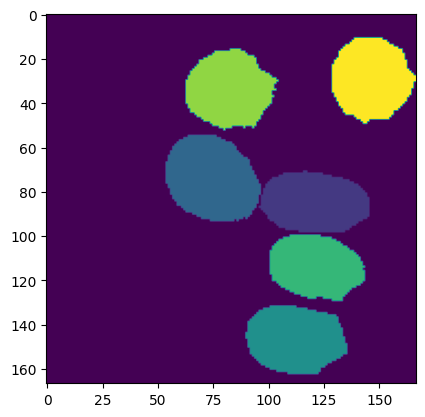

In [30]:
nucl_labels = nucl_segm_vol[:,:,NUCL_LABELS_CHANNEL_ID]
nucl_labels_zmax = np.max(nucl_labels,axis=1)

plt.imshow(nucl_labels_zmax[0])

## Btrack

In [105]:
objs=btrack.io.segmentation_to_objects(segmentation=nucl_labels, intensity_image=nucl_vol, scale=resolution)

with btrack.BayesianTracker() as tracker:

    # configure the tracker using a config file
    tracker.configure(BTRACK_CELL_MODEL_PATH)

    # append the objects to be tracked
    tracker.append(objs)

    # set the volume (Z axis volume limits default to [-1e5, 1e5] for 2D data)
    xmax = xlim * resolution[2]
    ymax = ylim * resolution[1]
    zmax = zlim * resolution[0]
    tracker.volume = ((0, xmax), (0, ymax), (0, zmax))

    tracker.max_search_radius = 20

    # track them (in interactive mode)
    tracker.track(step_size=100)

    # generate hypotheses and run the global optimizer
    tracker.optimize()

    # get the tracks as a python list
    tracks = tracker.tracks

    # optional: get the data in a format for napari
    data, properties, graph = tracker.to_napari()
    tracker.export(CT_BTRACK_RES_PATH, obj_type='obj_type_1')

[INFO][2026/06/08 10:58:26 AM] Localizing objects from segmentation...
INFO:btrack.io._localization:Localizing objects from segmentation...
progress: 100%|██████████| 4/4 [00:00<00:00, 35.11it/s]
[INFO][2026/06/08 10:58:26 AM] Objects are of type: <class 'dict'>
INFO:btrack.io.utils:Objects are of type: <class 'dict'>
[INFO][2026/06/08 10:58:26 AM] ...Found 24 objects in 4 frames.
INFO:btrack.io._localization:...Found 24 objects in 4 frames.
[INFO][2026/06/08 10:58:26 AM] Loaded btrack: C:\Users\voland\.conda\envs\tracking-env\Lib\site-packages\btrack\libs\libtracker.DLL
INFO:btrack.libwrapper:Loaded btrack: C:\Users\voland\.conda\envs\tracking-env\Lib\site-packages\btrack\libs\libtracker.DLL
[INFO][2026/06/08 10:58:26 AM] Starting BayesianTracker session
INFO:btrack.core:Starting BayesianTracker session
[INFO][2026/06/08 10:58:26 AM] Loading configuration file: ..\..\models\btrack\cell_config.json
INFO:btrack.config:Loading configuration file: ..\..\models\btrack\cell_config.json
[INF

In [113]:
nucl_btrack_data = pd.DataFrame(data,columns=["track_id","T","Zum","Yum","Xum"])
nucl_btrack_data[["Z","Y","X"]] = (nucl_btrack_data[["Zum","Yum","Xum"]] /resolution).astype(int)
nucl_btrack_data.to_csv(NUCL_BTRACK_DATA_PATH)

In [103]:
tracks_ids = nucl_btrack_data["track_id"].unique()

traj_nucl_vol = np.zeros(nucl_vol.shape, dtype = nucl_vol.dtype)
for track_i in tracks_ids:
    tracks_objs = nucl_btrack_data.loc[nucl_btrack_data["track_id"]==track_i][["T","Z","Y","X"]].values.astype(int)

    for i in range(1,len(tracks_objs)):
        _,_,prev_y,prev_x = tracks_objs[i-1]
        t,z,y,x = tracks_objs[i]
        
        traj_nucl_vol[t,z] = cv2.line(traj_nucl_vol[t,z],(x,y),(prev_x,prev_y),color = track_i)
        traj_nucl_vol[t,z] = cv2.circle(traj_nucl_vol[t,z],center = (x,y),color = track_i, radius = 2)

In [104]:
nucl_btrack_vol = visualization.add_texts_4D(nucl_vol, nucl_btrack_data.astype(int), text_col = "track_id")
btrack_nucl_composite = np.stack([nucl_vol,nucl_btrack_vol,traj_nucl_vol,bf_vol],axis=2)
tifffile.imwrite(NUCL_BTRACK_VOL_PATH,btrack_nucl_composite,imagej=True,compression="zlib")

### Ultrack

In [ ]:
detection, edges = labels_to_contours(nucl_labels, sigma=4.0)  # multiple labels can be used with [labels_0, labels_1, ...]

Converting labels to contours: 100%|██████████| 4/4 [00:00<00:00, 16.45it/s]


In [ ]:
config = load_config(ULTRACK_CONFIG_PATH)
#config =  MainConfig()  # or load default config
#config.segmentation_config.threshold = 0.5
pprint(config)

MainConfig(
│   data_config=DataConfig(
│   │   n_workers=1,
│   │   working_dir=WindowsPath('.'),
│   │   database='sqlite',
│   │   address=None,
│   │   in_memory_db_id=0
│   ),
│   segmentation_config=SegmentationConfig(
│   │   min_area=500,
│   │   max_area=10000,
│   │   n_workers=1,
│   │   min_frontier=0.0,
│   │   threshold=0.5,
│   │   max_noise=0.0,
│   │   random_seed='frame',
│   │   ws_hierarchy=<function watershed_hierarchy_by_area at 0x0000028EC69C81F0>,
│   │   anisotropy_penalization=0.0
│   ),
│   linking_config=LinkingConfig(
│   │   max_distance=5.0,
│   │   n_workers=1,
│   │   max_neighbors=5,
│   │   distance_weight=0.0,
│   │   z_score_threshold=5.0
│   ),
│   tracking_config=TrackingConfig(
│   │   solver_name='',
│   │   appear_weight=-0.002,
│   │   disappear_weight=-0.01,
│   │   division_weight=-0.001,
│   │   image_border_size=None,
│   │   n_threads=0,
│   │   window_size=100,
│   │   overlap_size=5,
│   │   solution_gap=0.0,
│   │   time_limit=120000,
│   │   method=0,
│   │   link_function='power',
│   │   power=4.0,
│   │   bias=0.0,
│   │   dismiss_weight_guess=None,
│   │   include_weight_guess=None
│   )
)

In [ ]:
track(
    config,
    detection=detection,
    edges=edges,
    scale=resolution,
    overwrite=True,
)

C:\Users\voland\AppData\Local\Temp\3\ipykernel_33624\709090922.py:1: DeprecationWarning: Argument detection is deprecated, please use foreground instead.
  track(
Linking nodes.: 100%|██████████| 3/3 [00:00<00:00, 16.53it/s]


Using Coin-OR Branch and Cut solver
Solving ILP batch 0
Constructing ILP ...
Solving ILP ...
Saving solution ...
Done!


In [ ]:
tracks_df, graph = to_tracks_layer(config)

In [ ]:
tracks_df.to_csv(NULCL_ULTRACK_RES_PATH, index=False)